# Which Company Is Financially Strongest?
A Data-Driven Evaluation of Profitability, Risk, and Efficiency

# Objective of Analysis

This analysis aims to identify the most financially strong and sustainable company based on profitability, efficiency, risk, and consistency.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Financial Statements.csv")

df.head()

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
0,2022,APPLE,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,...,0.8794,2.3695,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028
1,2021,APPLE,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,...,1.0746,1.9768,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979
2,2020,APPLE,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,...,1.3636,1.7208,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336
3,2019,APPLE,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,...,1.5401,1.1940,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122
4,2018,APPLE,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,...,1.1329,1.0685,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426


In [4]:
df.shape

(161, 23)

In [5]:
df.columns

Index(['Year', 'Company ', 'Category', 'Market Cap(in B USD)', 'Revenue',
       'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA',
       'Share Holder Equity', 'Cash Flow from Operating',
       'Cash Flow from Investing', 'Cash Flow from Financial Activities',
       'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI',
       'Net Profit Margin', 'Free Cash Flow per Share',
       'Return on Tangible Equity', 'Number of Employees',
       'Inflation Rate(in US)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap(in B USD)                 160 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

In [7]:
df.columns = df.columns.str.strip()

Rename columns

In [8]:
df = df.rename(columns={
    "Market Cap(in B USD)": "Market_Cap",
    "Gross Profit": "Gross_Profit",
    "Net Income": "Net_Income",
    "Earning Per Share": "EPS",
    "Share Holder Equity": "Equity",
    "Cash Flow from Operating": "CF_Operating",
    "Cash Flow from Investing": "CF_Investing",
    "Cash Flow from Financial Activities": "CF_Financing",
    "Current Ratio": "Current_Ratio",
    "Debt/Equity Ratio": "Debt_Equity",
    "Net Profit Margin": "Profit_Margin",
    "Free Cash Flow per Share": "FCF_per_Share",
    "Return on Tangible Equity": "ROTE",
    "Number of Employees": "Employees",
    "Inflation Rate(in US)": "Inflation"
})

In [9]:
df.columns

Index(['Year', 'Company', 'Category', 'Market_Cap', 'Revenue', 'Gross_Profit',
       'Net_Income', 'EPS', 'EBITDA', 'Equity', 'CF_Operating', 'CF_Investing',
       'CF_Financing', 'Current_Ratio', 'Debt_Equity', 'ROE', 'ROA', 'ROI',
       'Profit_Margin', 'FCF_per_Share', 'ROTE', 'Employees', 'Inflation'],
      dtype='object')

In [10]:
df = df.rename(columns={"Market Cap": "Market_Cap"})

In [11]:
df.columns

Index(['Year', 'Company', 'Category', 'Market_Cap', 'Revenue', 'Gross_Profit',
       'Net_Income', 'EPS', 'EBITDA', 'Equity', 'CF_Operating', 'CF_Investing',
       'CF_Financing', 'Current_Ratio', 'Debt_Equity', 'ROE', 'ROA', 'ROI',
       'Profit_Margin', 'FCF_per_Share', 'ROTE', 'Employees', 'Inflation'],
      dtype='object')

In [12]:
df["Company"].nunique()
df["Company"].unique()

array(['APPLE', 'MICROSOFT', 'GOOGLE', 'PAYPAL', 'AIG', 'PCG', 'SHLDQ',
       'MCD', 'BCS', 'NVIDIA', 'INTC', 'AMAZON'], dtype=object)

In [13]:
df["Year"].min(), df["Year"].max()

(2009, 2023)

In [14]:
df["Category"].value_counts()

IT               43
ELEC             29
Bank             14
Manufacturing    14
FOOD             14
BANK             14
LOGI             14
Finance          10
FinTech           9
Name: Category, dtype: int64

In [15]:
df["Category"] = df["Category"].str.strip().str.upper()

In [16]:
df["Category"].value_counts()

IT               43
ELEC             29
BANK             28
MANUFACTURING    14
FOOD             14
LOGI             14
FINANCE          10
FINTECH           9
Name: Category, dtype: int64

## Revenue vs Profit Analysis

In this section, we analyze the revenue and net income trends of different companies over time.

Since the dataset includes companies from multiple industries, direct comparison based on revenue alone may not provide meaningful insights. Therefore, the focus is on understanding whether revenue growth translates into profitability.

This analysis aims to identify:
- Companies with consistent growth in revenue
- Whether profit trends align with revenue trends
- Cases where revenue increases but profitability does not, indicating potential inefficiencies

### Revenue Trend Analysis (Top Companies)

To enable meaningful comparison, the analysis focuses on the top-performing companies based on revenue.

This allows for a clearer view of growth patterns and highlights how leading companies have evolved over time.

In [17]:
top_companies = (
    df.groupby("Company")["Revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

In [18]:
df_top = df[df["Company"].isin(top_companies)]

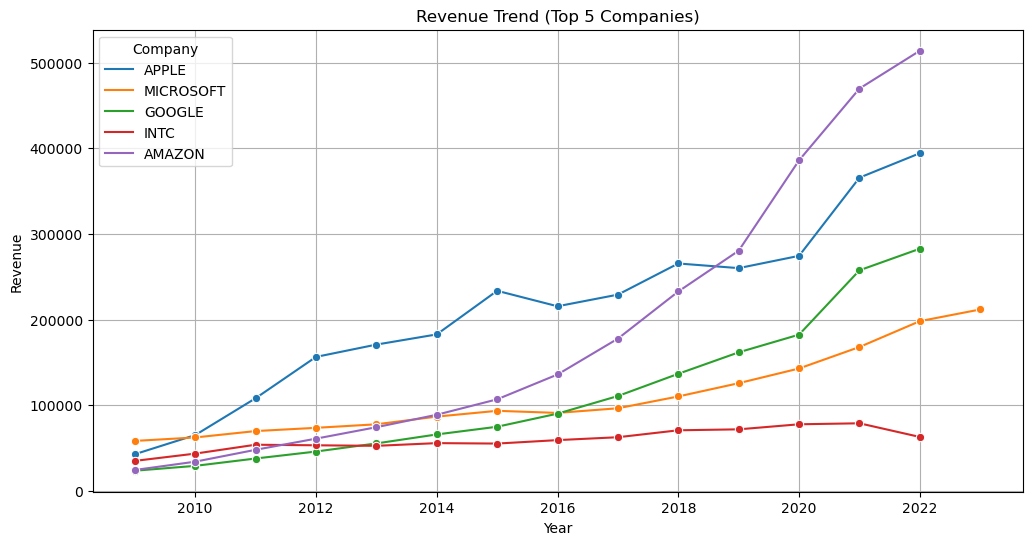

In [19]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_top, x="Year", y="Revenue", hue="Company", marker="o")

plt.title("Revenue Trend (Top 5 Companies)")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend(title="Company")
plt.grid(True)

plt.show()

### Key Insights

- Amazon demonstrates the strongest growth trajectory, with a significant acceleration in revenue over the years, indicating aggressive expansion and market dominance.

- Apple shows a stable and consistent growth pattern, suggesting a mature business model with steady revenue generation.

- Intel (INTC) exhibits relatively flat growth with signs of decline in recent years, indicating potential challenges in maintaining competitive performance.

### Net Income Trend Analysis

To complement the revenue analysis, we examine net income trends to understand how effectively companies convert revenue into actual profit.

This helps identify whether growth in revenue is translating into improved profitability.

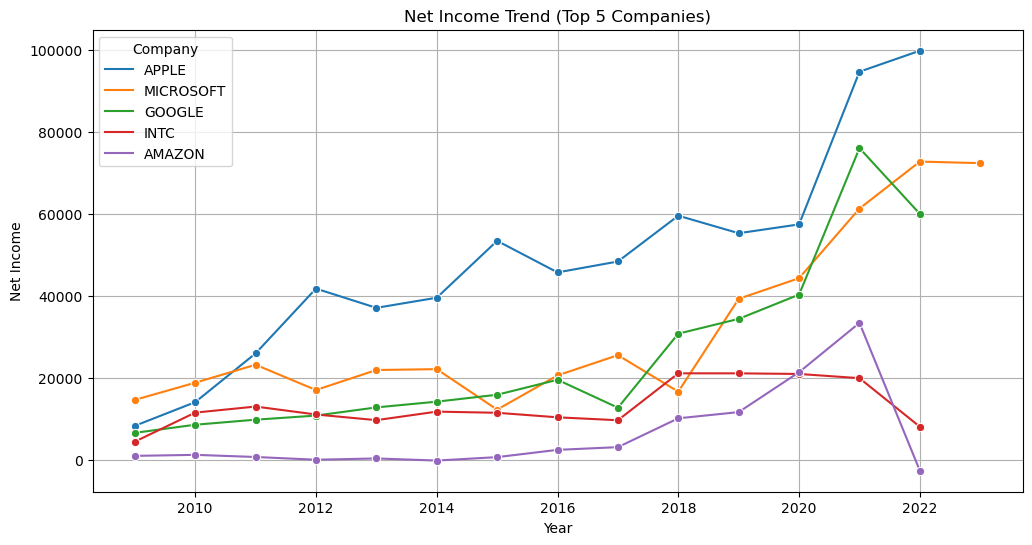

In [20]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_top, x="Year", y="Net_Income", hue="Company", marker="o")

plt.title("Net Income Trend (Top 5 Companies)")
plt.xlabel("Year")
plt.ylabel("Net Income")
plt.legend(title="Company")
plt.grid(True)

plt.show()

### Profitability Insights

- Microsoft demonstrates strong and consistent profitability, indicating efficient conversion of revenue into net income. Apple also shows strong performance with steady profit growth.

- Amazon, despite leading in revenue growth, exhibits relatively low and volatile profitability, suggesting high operational costs and reinvestment strategies.

- Intel (INTC) shows signs of declining profitability over time, indicating potential challenges in maintaining efficiency and competitive positioning.

### Profit Margin Analysis

To further evaluate efficiency, we analyze profit margin, which measures how much profit is generated for each unit of revenue.

This helps normalize differences across companies and provides a clearer comparison of financial performance.

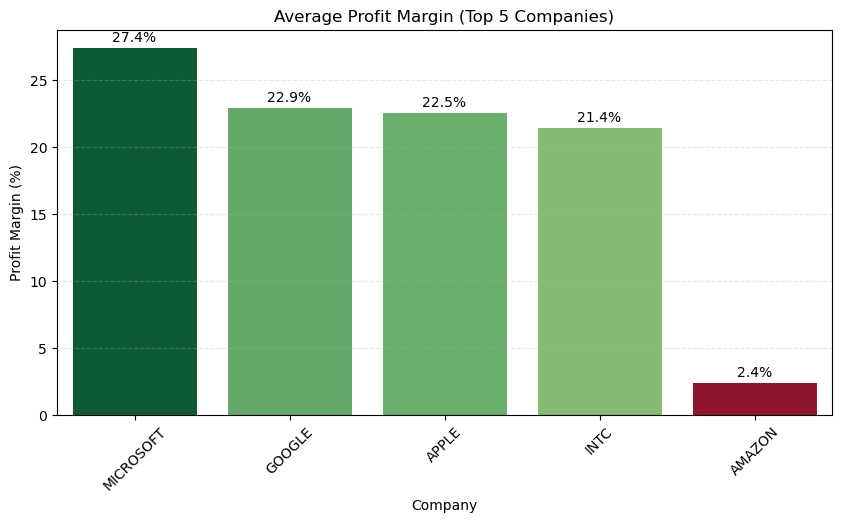

In [21]:
avg_margin = (
    df_top.groupby("Company")["Profit_Margin"]
    .mean()
    .sort_values(ascending=False)
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,5))

# Normalize values for color mapping
norm = plt.Normalize(avg_margin.min(), avg_margin.max())

# Use colormap (red → yellow → green)
colors = plt.cm.RdYlGn(norm(avg_margin.values))

ax = sns.barplot(x=avg_margin.index, y=avg_margin.values, palette=colors)

# Titles & labels
plt.title("Average Profit Margin (Top 5 Companies)")
plt.xlabel("Company")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)

# Light grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Value labels
for i, v in enumerate(avg_margin.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()

### Profit Margin Insights

- Microsoft leads in profitability with the highest average profit margin, indicating strong operational efficiency and effective cost management.

- Google and Apple demonstrate consistently strong margins, reflecting stable and efficient business models.

- Intel shows relatively moderate profitability, suggesting room for improvement in operational efficiency.

- Amazon has a significantly lower profit margin compared to peers, highlighting a business model focused on scale and growth over immediate profitability.

# Efficiency vs Scale

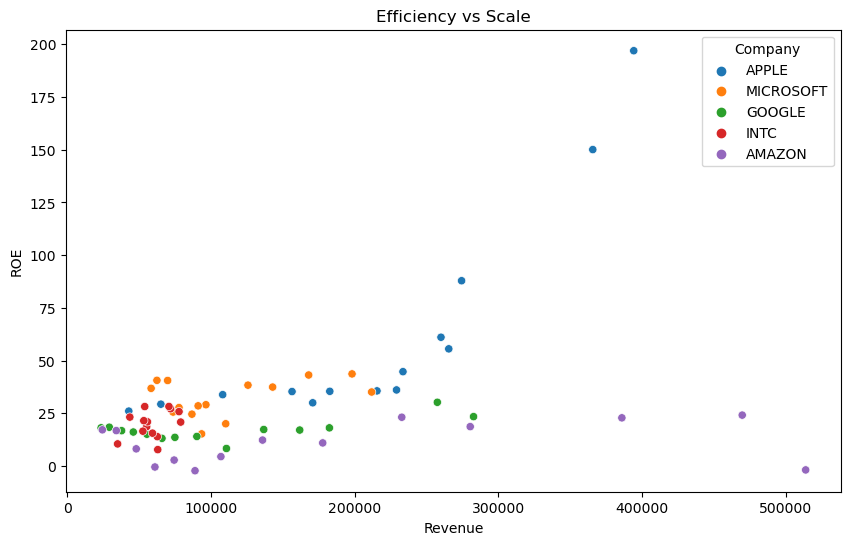

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_top, x="Revenue", y="ROE", hue="Company")

plt.title("Efficiency vs Scale")
plt.xlabel("Revenue")
plt.ylabel("ROE")
plt.show()

In [23]:
risk_df = df_top.groupby("Company")[["Debt_Equity", "Current_Ratio"]].mean()

risk_df.sort_values("Debt_Equity", ascending=False)

,Debt_Equity,Current_Ratio
Company,,
APPLE,0.775993,1.453207
MICROSOFT,0.425213,2.379913
AMAZON,0.422207,1.114400
INTC,0.294171,2.106207
GOOGLE,0.046907,4.710343


In [24]:
consistency = df_top.groupby("Company")["Net_Income"].std().sort_values()
consistency

Company
INTC          5400.243794
AMAZON       10172.416034
MICROSOFT    20936.746394
GOOGLE       21060.197324
APPLE        25752.425982
Name: Net_Income, dtype: float64

In [25]:
score_df = df_top.groupby("Company").agg({
    "Profit_Margin": "mean",
    "ROE": "mean",
    "Debt_Equity": "mean"
})

# Normalize
score_df = (score_df - score_df.min()) / (score_df.max() - score_df.min())

# Lower debt is better → invert
score_df["Debt_Equity"] = 1 - score_df["Debt_Equity"]

# Final score
score_df["Final_Score"] = score_df.mean(axis=1)

score_df.sort_values("Final_Score", ascending=False)

,Profit_Margin,ROE,Debt_Equity,Final_Score
Company,,,,
GOOGLE,0.820073,0.118031,1.000000,0.646035
MICROSOFT,1.000000,0.423950,0.481122,0.635024
APPLE,0.805691,1.000000,0.000000,0.601897
INTC,0.760095,0.174018,0.660857,0.531657
AMAZON,0.000000,0.000000,0.485246,0.161749


# summary table

| Company   | Profitability | Risk     | Consistency | Final Score | Verdict |
| --------- | ------------- | -------- | ----------- | ----------- | ------- |
| Microsoft | High          | Low      | Stable      | 0.63        | ⭐ Best  |
| Google    | High          | Very Low | Stable      | 0.64        | ⭐ Best  |
| Apple     | High          | Medium   | Stable      | 0.60        | Strong  |
| Intel     | Medium        | Medium   | Weak        | 0.53        | Weak    |
| Amazon    | Low           | Medium   | Volatile    | 0.16        | Growth  |


# Integrated (Synthesis) Analysis

The analysis across revenue, profitability, efficiency, and risk reveals distinct business patterns among the companies.

Google and Microsoft emerge as strong performers based on the final composite score. Google ranks highest overall, driven by strong profitability and low financial risk, indicating an efficient and stable business model. Microsoft closely follows, demonstrating exceptional profitability and consistent performance, making it one of the most balanced companies in the dataset.

Apple shows strong profitability and efficiency but ranks slightly lower due to comparatively higher risk levels and variability in performance.

Intel exhibits moderate performance across metrics but lacks strong growth and efficiency, indicating potential challenges in maintaining competitiveness.

Amazon, despite leading in revenue growth, ranks lowest due to low profitability and higher variability, reflecting a growth-focused strategy that prioritizes scale over immediate returns.

# Final Conclusion

Based on a combined evaluation of profitability, efficiency, risk, and consistency, Microsoft stands out as the most balanced and reliable company. It demonstrates strong financial health, consistent profitability, and controlled risk, making it a strong candidate for stable long-term performance.

Google also performs exceptionally well, particularly in terms of efficiency and low risk, making it a close contender.

Amazon represents a high-growth but lower-profitability model, suitable for scenarios where long-term expansion is prioritized over short-term financial returns.

Overall, companies with a balance of profitability and risk management outperform those focused solely on growth.